# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:

# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')


In [3]:
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


- plans: Solo existen dos tipos de planes, el dtype de cada columna es adecuado para su análisis
- users: Cambair dtype a date  para "churn_date" y "reg_date". Revisar nulos en "churn_date" y "city"
- usage: Cambair dtype a date para "date". Revisar nulos en ["date","duration","lenght"]

---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print("Nulos users:\n",users.isna().sum())


print("Proporción:\n",users.isna().mean().sort_values())


Nulos users:
 user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
Proporción:
 user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
reg_date      0.00000
plan          0.00000
city          0.11725
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print("Nulos usage:\n",usage.isna().sum())


print("Proporción:\n",usage.isna().mean().sort_values())

Nulos usage:
 id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
Proporción:
 id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
length      0.44740
duration    0.55190
dtype: float64


 **Conclusiones y Recomendaciones**:

- Valores nulos en usage["date"] (<1%). La proporción de valores faltantes es marginal, por lo que no afecta significativamente el análisis.
Acción: imputar utilizando una medida de tendencia central.
- Valores nulos en usage["duration"] y usage["length"]. La ausencia de datos responde a la naturaleza del dataset, que combina registros de llamadas y mensajes.
Acción: segmentar el dataset por tipo de evento y analizar cada uno de forma independiente. No se recomienda imputación ni eliminación, ya que los nulos son estructurales, no errores.
- Valores nulos en users["churn_date"].La alta proporción de nulos indica que la mayoría de los usuarios continúan activos, comportamiento esperado.
Acción: crear una variable binaria (churn_flag) para diferenciar usuarios activos vs inactivos, y realizar análisis segmentado para identificar patrones de abandono (churn).

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `age` presenta posibles sentinel (-999)

In [13]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000



- Posibles sentinels en "duration" y "lenght" duración o longitud con valor 0.
- Los valores máximos en las columnas númericas parecen ser valores lógicos debido a la naturaleza del dataset, aun que con valores extremos.


In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe(include='object')



,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- Bogotá es la ciudad con mayor participación de usuarios, alrededor del 22%.
- La columna `plan` muestra solo 2 tipos de tarifas, siendo "Básico" las más popular entre los usuarios con el 64.8% del total.

In [15]:
# explorar columna categórica de usage
usage['type'].describe(include='object')

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` contiene únicamente 2 tipos de comunicación siendo texto el más popular entre los usuarios(>50%) .


---
**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  En "duration" y "Lenght", "age" y "city"
- ¿Qué acción tomarías? , Colocar una columna sentinels_flags y analizar la cantidad de sentinel en ambas columnas para poder decidir si se eliminan, capan o se ignoran.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'],errors="coerce")

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'],errors="coerce")

In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`,existen registros del 2026, que posiblemente sean registros obtenidos hasta el momento de generar este dataset.

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, Todos los registros corresponden a 2024, lo que sugiere una cohorte única de ese año.
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? No existen años atipicos solo datos nulos
- ¿Qué harías con ellas? En caso de existiera algun año atípico para este dataset en particular, lo imputaria con la moda (2024), ya que todo el dataset sugiere registros de una cohorte única de ese año.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:

# Reemplazar -999 por la mediana de age
age_mediana = users["age"].median()

users['age'] = users["age"].replace(-999,age_mediana)

# Verificar cambios
users['age'].unique()



array([38., 53., 57., 69., 63., 61., 39., 70., 76., 47., 67., 60., 78.,
       77., 25., 51., 74., 64., 26., 68., 37., 42., 36., 22., 28., 32.,
       40., 44., 49., 43., 79., 59., 46., 56., 58., 50., 54., 33., 24.,
       29., 45., 66., 30., 35., 65., 18., 55., 19., 23., 41., 27., 34.,
       72., 75., 31., 71., 52., 20., 73., 21., 62., 48.])

In [21]:
# Reemplazar ? por NA en city
users['city'] = users["city"].replace("?",pd.NA)

# Verificar cambios
users["city"].unique()

array(['Medellín', <NA>, 'CDMX', 'Bogotá', 'GDL', 'MTY', nan, 'Cali'],
      dtype=object)

In [22]:
# Marcar fechas futuras como NA para reg_date
users["reg_date"]=users["reg_date"].where(users["reg_date"].dt.year <= 2024)
# Verificar cambios
users["reg_date"].dt.year.unique()

array([2022.,   nan, 2023., 2024.])

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
usage["duration"].isna().groupby(usage["type"]).mean()

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage["length"].isna().groupby(usage["type"]).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64


* Los registros de tipo "text" no presentan valores en la columna "duration", mientras que los de tipo "call" no presentan valores en "length".
* Los valores nulos en "duration" y "length" son estructurales (missing by design), ya que dependen del tipo de evento, por lo que se conservan y no requieren imputación.
* Se identifica un porcentaje menor al 1% de registros que no siguen este patrón esperado.


In [25]:
#Cantidad de registros "call" que no cumplen el patrón
len(usage[(usage["type"]=="call") & (usage["length"].isna()==False)])

12

In [26]:
#Cantidad de registros "text" que no cumplen el patrón
len(usage[(usage["type"]=="text") & (usage["duration"].isna()==False)])

16

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
* Se encontró que existen registros de tipo "text" con valores en la columna "duration" (120)
* Al igual que registros de tipo "call" con valores en "length" (1490)
* Estos registros representan menos del 1% por lo que no se tomarán en cuenta para el analisis

In [27]:
#Dataset de usage con registros validos
calls_valid = (usage["type"] == "call") & (usage["length"].isna())
texts_valid = (usage["type"] == "text") & (usage["duration"].isna())

usage_clean = usage[calls_valid | texts_valid].copy()

In [28]:
#Comprobación
usage_clean.describe()

,id,user_id,duration,length
count,39972.000000,39972.000000,17896.000000,22076.000000
mean,20000.186105,12002.323301,5.101985,51.348840
std,11546.786015,1157.224097,5.923969,45.651973
min,1.000000,10000.000000,0.000000,0.000000
25%,9999.750000,10996.000000,1.437500,37.000000
50%,19997.500000,12013.000000,3.500000,50.000000
75%,30002.250000,13004.250000,6.970000,64.000000
max,40000.000000,13999.000000,120.000000,1490.000000


---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [29]:


# Columnas auxiliares
usage_clean["is_text"] = (usage_clean["type"] == "text").astype(int) #conocer el total de mensajes
usage_clean["is_call"] = (usage_clean["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage_clean.groupby("user_id").agg(
    cant_mensajes=("is_text","sum"),
    cant_llamadas=("is_call","sum"),
    cant_minutos_llamada=("duration","sum")
).reset_index()


# observar resultado
usage_agg.head(3)



,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [30]:
# Renombrar columnas

# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [31]:
# Combinar la tabla agregada con el dataset de usuarios

user_profile = pd.merge(users,usage_agg,on=["user_id"], how= "inner")
user_profile.head(5)



,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [32]:
# Resumen estadístico de las columnas numéricas
users_2024=user_profile[user_profile["reg_date"].dt.year==2024]
print(users_2024.describe())
print()
print("Mediana:")
print(users_2024.median())

            user_id          age  cant_mensajes  cant_llamadas  \
count   1330.000000  1330.000000    1330.000000    1330.000000   
mean   13332.699248    48.414286       5.493233       4.554887   
std      384.969999    17.963443       2.381652       2.138981   
min    12666.000000    18.000000       0.000000       0.000000   
25%    12999.250000    33.000000       4.000000       3.000000   
50%    13333.500000    48.000000       5.000000       4.000000   
75%    13665.750000    64.000000       7.000000       6.000000   
max    13999.000000    79.000000      16.000000      13.000000   

       cant_minutos_llamada  
count           1330.000000  
mean              23.312278  
std               17.024838  
min                0.000000  
25%               11.302500  
50%               20.185000  
75%               32.060000  
max              155.690000  

Mediana:
user_id                 13333.500
age                        48.000
cant_mensajes               5.000
cant_llamadas          

In [33]:

# Distribución porcentual del tipo de plan
users_2024["plan"].value_counts(normalize=True)


Basico     0.656391
Premium    0.343609
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

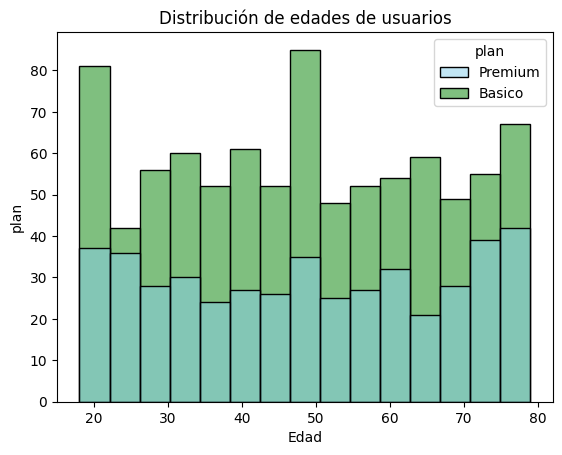

In [34]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=users_2024,
    x="age",
    bins=15,
    hue="plan",
    palette=['skyblue','green']
)
plt.title("Distribución de edades de usuarios")
plt.xlabel("Edad")
plt.ylabel("plan")
plt.show()

💡Insights: 
- Se presenta una distribución multimodal en los usuarios registrados en 2024, los grupos de edad entre 18–25 y 45–50 años presentan mayor concentración, y dentro de estos rangos se observa una mayor presencia del plan Básico en comparación con Premium.”

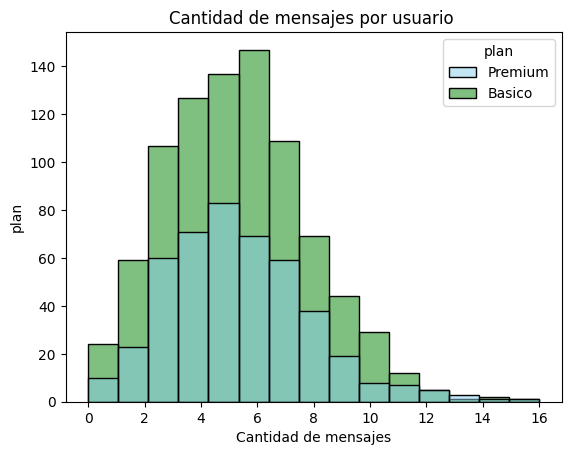

In [35]:

# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=users_2024,
    x="cant_mensajes",
    bins=15,
    hue="plan",
    palette=['skyblue','green']
)
plt.title("Cantidad de mensajes por usuario ")
plt.xlabel("Cantidad de mensajes")
plt.ylabel("plan")
plt.show()


💡Insights: 
- “La distribución de mensajes presenta un ligero sesgo a la derecha. Visualmente, los usuarios Premium muestran mayor presencia en valores altos de mensajes, lo que sugiere una posible mayor actividad en comparación con usuarios del plan Básico.”

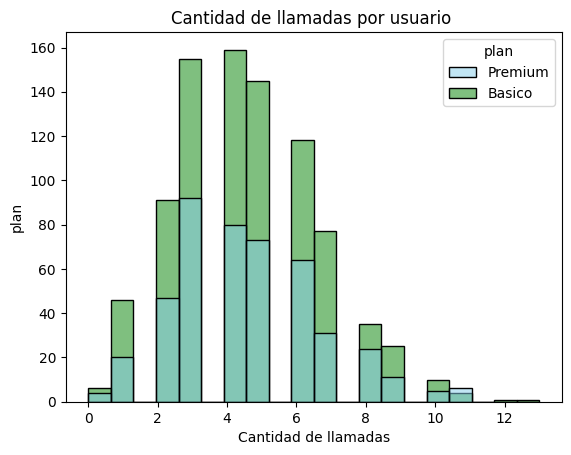

In [36]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=users_2024,
    x="cant_llamadas",
    bins=20,
    hue="plan",
    palette=['skyblue','green']
)
plt.title("Cantidad de llamadas por usuario ")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("plan")
plt.show()


💡Insights: 
- “La distribución de llamadas por usuario en 2024 muestra una concentración principal entre 3 y 6 llamadas mensuales, con una ligera asimetría positiva. Ambos planes presentan patrones de uso similares, aunque los usuarios Premium muestran una ligera mayor presencia en valores altos, lo que podría indicar un mayor nivel de uso en segmentos específicos.”

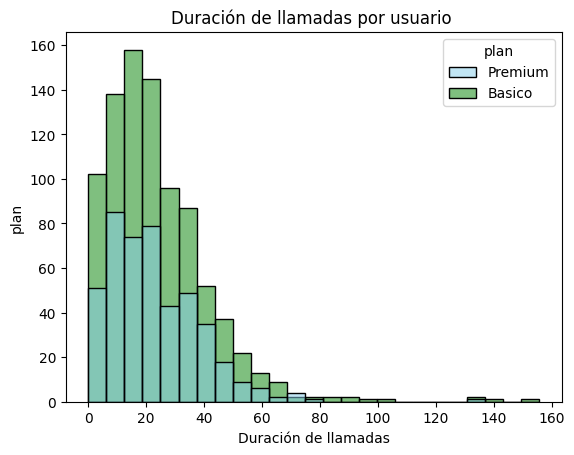

In [37]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=users_2024,
    x="cant_minutos_llamada",
    bins=25,
    hue="plan",
    palette=['skyblue','green']
)
plt.title("Duración de llamadas por usuario ")
plt.xlabel("Duración de llamadas")
plt.ylabel("plan")
plt.show()


💡Insights: -La suración de las llamadas tiene un sesgo a la derecha, alguno usuarios del plan básico han realizado llamadas de mas de 2 horas, aun que la mayoria realiza llamadas de entre 15 y 25 minutos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

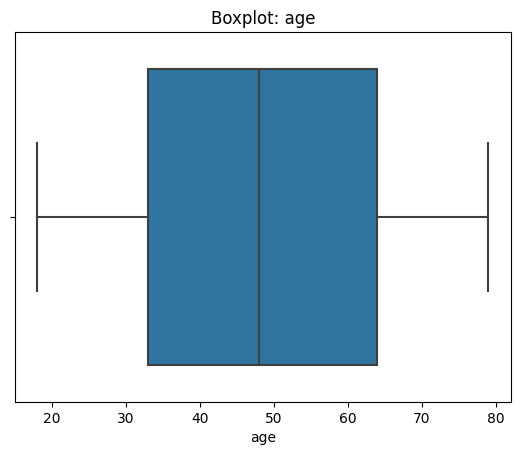

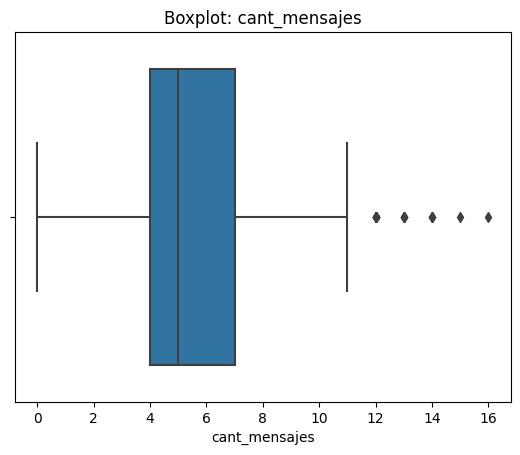

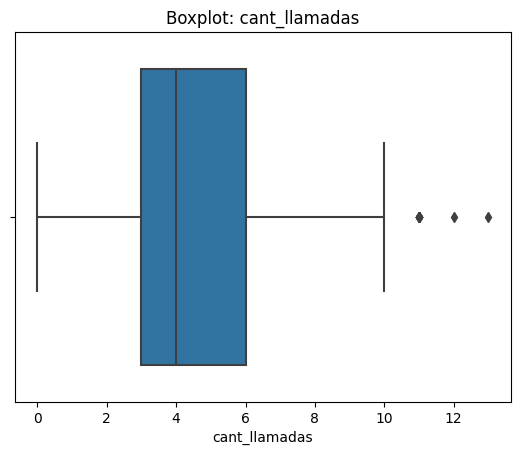

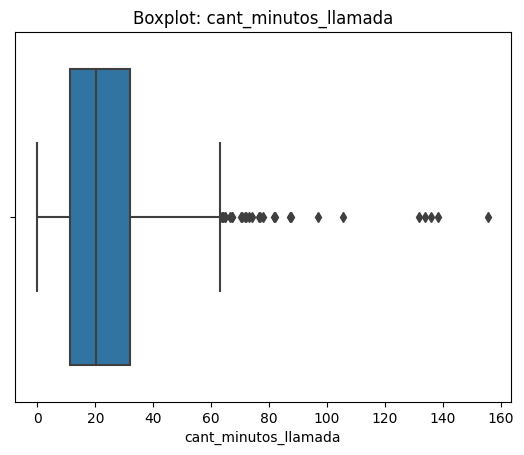

In [38]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=users_2024, x=col)
    plt.title(f'Boxplot: {col}'),
    plt.show()

💡Insights: 
- Age: No contiene Outliers
- cant_mensajes: Presenta Otliers.
- cant_llamadas: Presenta Outliers
- cant_minutos_llamada: Presenta Outliers, siendo la columna con outliers extremos.

In [39]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    Q1 = users_2024[col].quantile(0.25)
    Q3 = users_2024[col].quantile(0.75)
    IQR = Q3 - Q1
    
    upper = Q3 + 1.5 * IQR
    print("Limite superior en ",col,":",upper)



Limite superior en  cant_mensajes : 11.5
Limite superior en  cant_llamadas : 10.5
Limite superior en  cant_minutos_llamada : 63.196250000000006


In [40]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.520380,4.475119,22.831990
std,2.357817,2.142689,16.589736
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.095000
50%,5.000000,4.000000,19.730000
75%,7.000000,6.000000,31.185000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? Mantener, a pesar de estar fuera del limite superior, no son valores extremos y entran dentro de un comportamiento lógico
- cant_llamadas: mantener o no outliers, porqué? Mantener, a pesar de estar fuera del limite superior, no son valores extremos y entran dentro de un comportamiento lógico
- cant_minutos_llamada: mantener o no outliers, porqué? Manetener pero winsorizar para no sesgar analisis.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [41]:

# Crear columna grupo_uso
user_profile["grupo_uso"] = np.where(
    (user_profile["cant_mensajes"] < 5) | (user_profile["cant_llamadas"] < 5),
    "Bajo uso",
    np.where(
        (user_profile["cant_mensajes"] < 10) & (user_profile["cant_llamadas"] < 10),
        "Uso medio",
        "Alto uso"
    )
)

In [42]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Bajo uso
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Bajo uso
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Bajo uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [43]:
# Crear columna grupo_edad
user_profile["grupo_edad"]= np.where(
    (user_profile["age"] < 30),"Joven",
    np.where(
        (user_profile["age"] < 60),"Adulto","Adulto Mayor")
    )

In [44]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Bajo uso,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Bajo uso,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Bajo uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

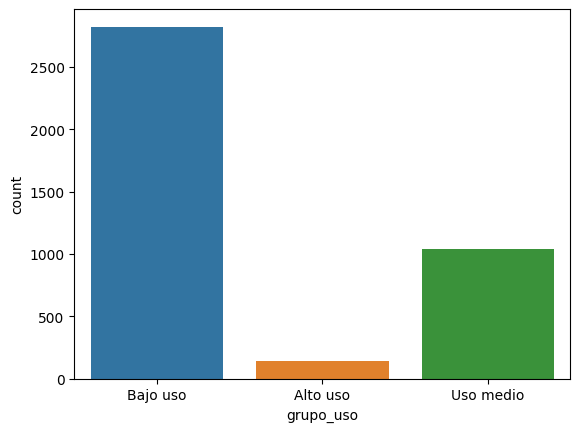

In [45]:

# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x="grupo_uso")

plt.show()


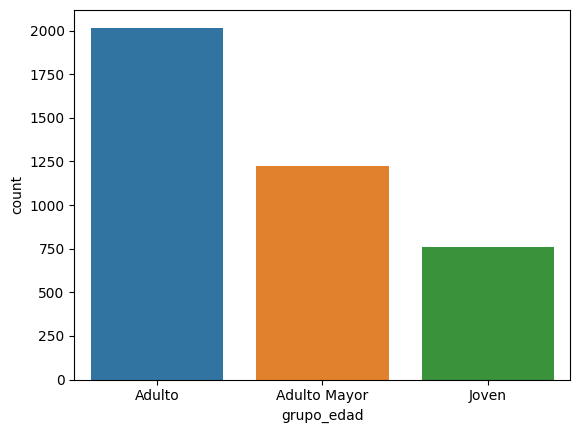

In [46]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x="grupo_edad")

plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo


⚠️ **Problemas detectados en los datos**
- Los registros de fechas en los datasets nbno contaban con el dtype adecuado
- 11.2% de los datos en "city son nulos, una cantidad que puede omitir información relevante en el análisis
-0.2% de valores nulos en "city", una cantidad de datosdespreciable que pueden ser eliminados sin afectar el análisis
-Registros sentinel en las columnas "city" y "age"
- Fuerte presencia de nulos en duration y lenght que reponden a la naturaleza del registro, las llamadas no tienen longitud solo duración, los mensajes de texto no tienen duración solo longitud.
Existe menos de un 1% de registros que no siguen el patron del resto de datos, registros mensjaes de texto y llamadas con valores en ambas columnas (duración y longitud), repitiendo el mismo valor, se infiere posibles sentinels

🔍 **Segmentos por Edad**

- Se cuentan con usurios desde los 18 hasta los 79 años
- Los grupos de principales de usuarios por edad son  los adultos de entre 30 y 60 años

📊 **Segmentos por Nivel de Uso**

- La mayoría de los usuarios están clasificados como bajo uso debido a las condiciones de llamadas y mensajes.


➡️ Esto sugiere que ...
-Los adultos son el grupo de edad mas importante para la empresa, seguido de los adultos mayores.
EL numero de mensajes incluidos en el plan básico es muy alto comparado con el promedio de mensajes usados por los usarios, en cuestion de llamadas, lo usuarios con mas llamadas realizadas son 12 mientras que la duración promedio es de 20min, una combinación que en los usuarios que se cumplen es el doble de los minutos del plan básico pero muy por debajo del plan premium.


💡 **Recomendaciones**

-  Analizar los niveles de consumo por separado, pues un cliente que realzia muchas llamadas pero pocos mensajes se clasifica como bajo uso, lo cual puede perder oportunidades para mejorar o ampliar los tipos de planes.
- Enfocarse en el segmenbto de adultos que concentra la mayor cantidad de usuarios.



---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`